# Day 26 of ML 30-Days Challenge

# Task

**Dimensionality Reduction (PCA, LDA, t-SNE)**: Learn techniques to reduce the number of features in a dataset. Understand Principal Component Analysis (PCA) for unsupervised reduction, Linear Discriminant Analysis (LDA) for supervised reduction, and t-SNE for visualization.

- **If Your Goal is Visualizing High-Dimensional Data by Class Separation:**<br>
 ***t-SNE*** is usually the best for visually distinguishing clusters and revealing complex, nonlinear structures, especially for exploratory data analysis or presenting results to humans.
  * Strength: Forms visually distinct clusters, even from complicated patterns.
  * Weakness: Non-deterministic, not suitable for downstream modeling, not interpretable, doesn’t preserve global structure well.
- **If Your Goal is Maximal Class Discrimination for Supervised Data:**<br>
 ***LDA*** is best if you have labeled data and your target is to maximize class separation in 2D/3D space.
  * Strength: Directly optimizes class separability.
  * Weakness: Assumes linear boundaries, requires enough samples per class.
- **If Your Goal is Capturing Variance/Structure for Both Visualization and Downstream Tasks:**<br>
 ***PCA*** is best for revealing axes of maximum variance and for use in preprocessing (e.g., before feeding to another algorithm).
  * Strength: Linear, deterministic, interpretable, good for noise reduction and data compression.
  * Weakness: Assumes linearity, doesn’t use labels, might miss complex separations.

In [20]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

###1. data generation

In [21]:
X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=5, n_redundant=2,
    n_classes=3, n_clusters_per_class=1, flip_y=0.1, random_state=42
)

rng = np.random.RandomState(42)
X += 0.5 * rng.normal(size=X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

###2. Dimensionality Reduction methods

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_pca

array([[-2.25555158,  2.47872543],
       [-0.58309744,  1.08415007],
       [-1.95764442, -1.94473105],
       ...,
       [ 0.40559276, -1.26550624],
       [-1.35276794, -1.62664548],
       [-0.95803715, -1.4925787 ]])

In [23]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

X_lda

array([[ 0.00978011,  0.19025975],
       [-1.73267503, -1.17482142],
       [ 0.57904153, -1.51810255],
       ...,
       [ 2.18373721,  0.18004193],
       [ 1.88517139, -1.08329739],
       [ 0.57877391, -0.2412369 ]])

In [24]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

X_tsne

array([[ -1.8138615,  -4.858768 ],
       [ 44.11156  ,   1.5319209],
       [-13.381544 , -19.076248 ],
       ...,
       [-21.854448 ,   6.9374795],
       [-16.601112 , -16.70796  ],
       [ -9.041472 ,  -2.993364 ]], dtype=float32)

###3. Plot 2D comparison graph including original data

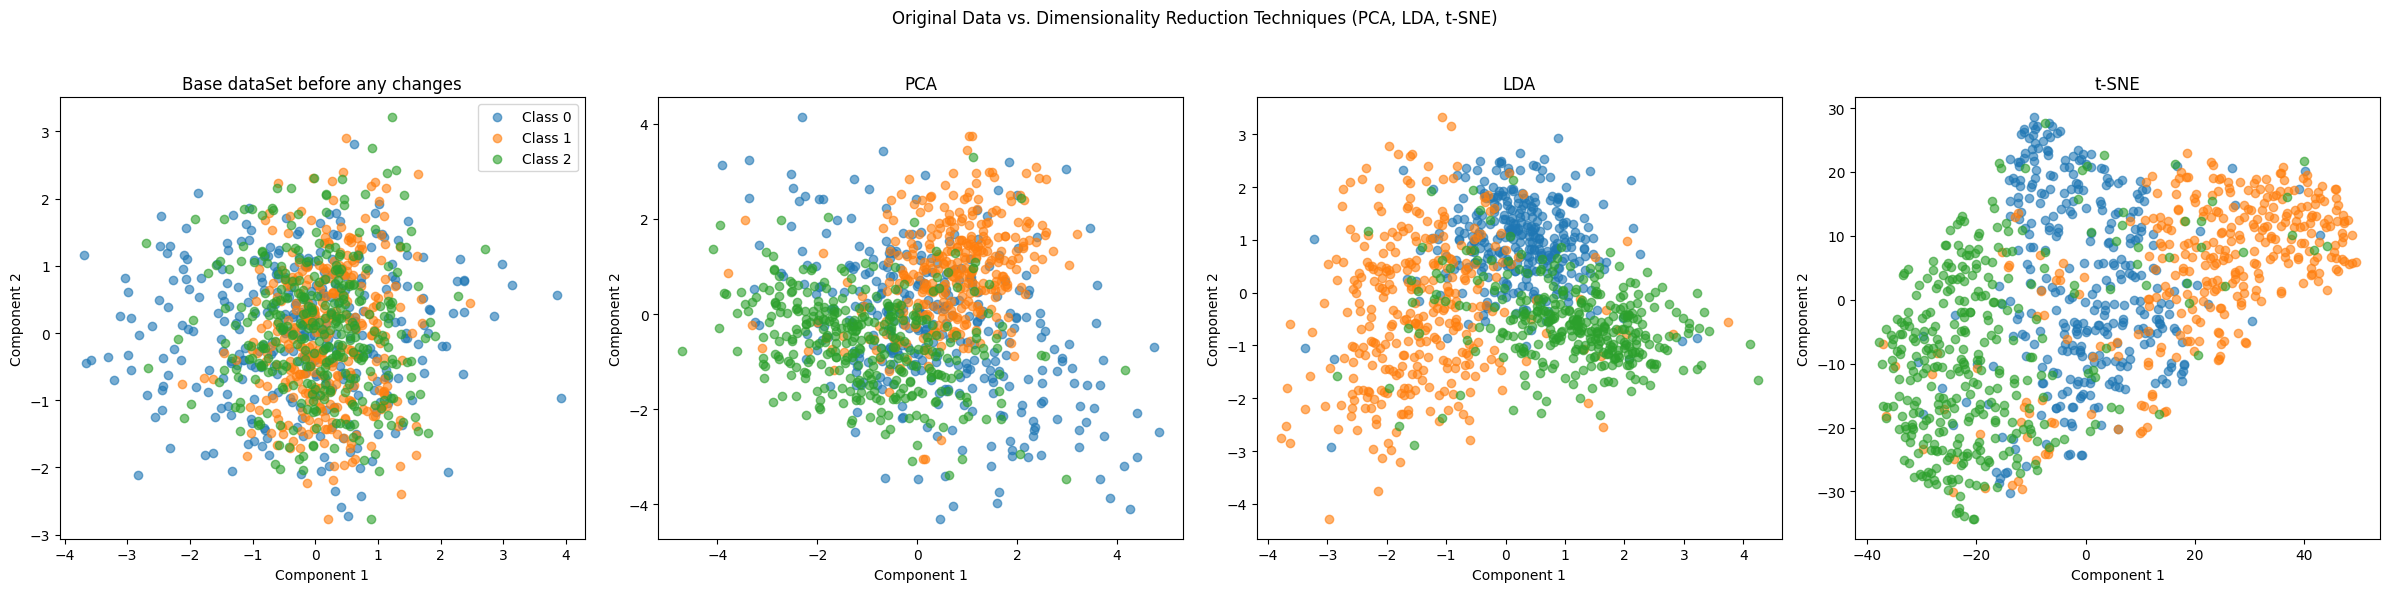

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
methods = [
    ('Base dataSet before any changes', X_scaled[:, :2]),
    ('PCA', X_pca),
    ('LDA', X_lda),
    ('t-SNE', X_tsne)
]

for ax, (name, data) in zip(axes, methods):
    for label in np.unique(y):
        ax.scatter(
            data[y == label, 0], data[y == label, 1],
            alpha=0.6, label=f"Class {label}"
        )
    ax.set_title(name)
    ax.set_xlabel('Component 1' if name != 'Raw Features (std. feat 1 vs feat 2)' else 'Feature 1')
    ax.set_ylabel('Component 2' if name != 'Raw Features (std. feat 1 vs feat 2)' else 'Feature 2')

axes[0].legend()
plt.suptitle("Original Data vs. Dimensionality Reduction Techniques (PCA, LDA, t-SNE)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()